## Choix du Dataset : Option A — Traduction (Seq2Seq)

Pour ce projet, nous allons utiliser le dataset **Tatoeba fra-eng** qui contient des paires de phrases anglais-français. Ce choix est idéal pour la partie III du projet car il correspond directement à l'implémentation d'un système Seq2Seq (Encoder-Decoder) pour la traduction, comme requis dans la suite des étapes. Le dataset est publiquement téléchargeable et permet de travailler avec des données réelles.

### TÉLÉCHARGEMENT ET CHARGEMENT DU DATASET

Cette section vise à télécharger le dataset Tatoeba fra-eng, à vérifier sa taille, à afficher des exemples bruts, puis à le limiter à un sous-ensemble raisonnable pour les besoins de l'entraînement.

In [6]:
# Importations nécessaires
import pandas as pd
import numpy as np
import random
import torch # Ajout de l'importation de torch

# Pour la reproductibilité
torch.manual_seed(42)
random.seed(42)
np.random.seed(42)

# Téléchargement du dataset Tatoeba fra-eng
print("Téléchargement du dataset Tatoeba fra-eng...")
!wget -nc https://www.manythings.org/anki/fra-eng.zip

# Décompression de l'archive
print("Décompression de l'archive...")
!unzip -n fra-eng.zip

# Chargement du dataset dans un DataFrame pandas
# Le fichier est 'fra.txt' et les colonnes sont séparées par des tabulations.
# Il y a aussi une colonne d'attribution que nous pouvons ignorer.
df = pd.read_csv('fra.txt', sep='\t', header=None, names=['english', 'french', 'attribution'])

print("Dataset chargé avec succès.")

Téléchargement du dataset Tatoeba fra-eng...
--2026-06-27 02:14:11--  https://www.manythings.org/anki/fra-eng.zip
Resolving www.manythings.org (www.manythings.org)... 173.254.30.110
Connecting to www.manythings.org (www.manythings.org)|173.254.30.110|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 8242175 (7.9M) [application/zip]
Saving to: ‘fra-eng.zip’

fra-eng.zip         100%[===================>]   7.86M  30.7MB/s    in 0.3s    

2026-06-27 02:14:12 (30.7 MB/s) - ‘fra-eng.zip’ saved [8242175/8242175]

Décompression de l'archive...
Archive:  fra-eng.zip
  inflating: _about.txt              
  inflating: fra.txt                 
Dataset chargé avec succès.


In [12]:
# 2. Vérifier la taille du corpus téléchargé (nombre de lignes / exemples)
print(f"Taille originale du corpus : {len(df)} paires de phrases.")

# 3. Afficher 5 exemples bruts pour prouver que le téléchargement a fonctionné
print("\nLes 5 premiers exemples bruts du dataset :")
display(df.head())

Taille originale du corpus : 240521 paires de phrases.

Les 5 premiers exemples bruts du dataset :


,english,french,english_len,french_len
0,Go.,Va !,1,2
1,Go.,Marche.,1,1
2,Go.,En route !,1,3
3,Go.,Bouge !,1,2
4,Hi.,Salut !,1,2


In [9]:
# 4. Limiter à un sous-ensemble raisonnable (ex. 20 000 à 50 000 paires, phrases courtes de moins de 10-12 mots)

# Supprimer la colonne 'attribution' car elle n'est pas nécessaire pour la traduction.
df = df.drop(columns=['attribution'])

# Calculer la longueur des phrases (nombre de mots)
df['english_len'] = df['english'].apply(lambda x: len(x.split()))
df['french_len'] = df['french'].apply(lambda x: len(x.split()))

# Filtrer les phrases courtes (moins de 12 mots)
MAX_SEQUENCE_LENGTH = 12
df_filtered = df[(df['english_len'] <= MAX_SEQUENCE_LENGTH) & (df['french_len'] <= MAX_SEQUENCE_LENGTH)].copy()

# Limiter le nombre total de paires à environ 30 000 pour un entraînement gérable
# Nous mélangeons d'abord les données pour avoir une sélection aléatoire.
NUM_SAMPLES = 30000
if len(df_filtered) > NUM_SAMPLES:
    df_subset = df_filtered.sample(n=NUM_SAMPLES, random_state=42).reset_index(drop=True)
else:
    df_subset = df_filtered.reset_index(drop=True)

print(f"\nNombre de paires après filtrage des phrases de plus de {MAX_SEQUENCE_LENGTH} mots : {len(df_filtered)}")
print(f"Taille finale du sous-ensemble utilisé : {len(df_subset)} paires de phrases.")

print("\nLes 5 premiers exemples du sous-ensemble filtré :")
display(df_subset.head())

# Supprimer les colonnes de longueur intermédiaires si elles ne sont plus nécessaires
df_subset = df_subset.drop(columns=['english_len', 'french_len'])


Nombre de paires après filtrage des phrases de plus de 12 mots : 231122
Taille finale du sous-ensemble utilisé : 30000 paires de phrases.

Les 5 premiers exemples du sous-ensemble filtré :


,english,french,english_len,french_len
0,I don't think I want to study French with you.,Je ne pense pas que je veuille étudier le fran...,10,12
1,That was the difficult part.,C'était la partie difficile.,5,4
2,Are the children at school?,Les enfants sont-ils à l'école ?,5,6
3,It's a robot.,C'est un robot.,3,3
4,I want to be pampered.,Je veux être choyée.,5,4


## 1. THÉORIE

Cette section aborde les concepts théoriques fondamentaux nécessaires à la compréhension et à l'implémentation des modèles de séquences. Nous couvrirons l'objectif probabiliste des modèles de langage, la notion de perplexité, le principe du Backpropagation Through Time (BPTT) et l'importance du gradient clipping.

### 1.1. Objectif probabiliste d'un modèle de langage et factorisation par règle de chaîne

Un modèle de langage (LM) a pour objectif d'apprendre la distribution de probabilité conjointe d'une séquence de mots $W = (w_1, w_2, \dots, w_T)$. Formellement, il estime $P(w_1, w_2, \dots, w_T)$.

Grâce à la règle de chaîne des probabilités, cette probabilité conjointe peut être factorisée comme suit :

$P(w_1, w_2, \dots, w_T) = P(w_1) \times P(w_2 | w_1) \times P(w_3 | w_1, w_2) \times \dots \times P(w_T | w_1, \dots, w_{T-1})$

Soit, de manière compacte :

$P(W) = \prod_{t=1}^{T} P(w_t | w_1, \dots, w_{t-1})$

L'objectif d'un modèle de langage est de maximiser cette probabilité (ou de minimiser le log-vraisemblance négatif, qui est équivalent) sur un corpus d'entraînement. En d'autres termes, pour chaque mot $w_t$ de la séquence, le modèle tente de prédire la probabilité du mot $w_t$ étant donné tous les mots précédents $w_1, \dots, w_{t-1}$. Cette approche permet au modèle de capturer les dépendances séquentielles et la structure grammaticale et sémantique du langage.

### 1.2. Notion de perplexité et son interprétation

La perplexité est une métrique couramment utilisée pour évaluer la qualité d'un modèle de langage. Elle mesure à quel point un modèle de probabilité prédit bien un échantillon. Une perplexité plus faible indique un meilleur modèle.

Formellement, la perplexité d'une séquence de $T$ mots $W = (w_1, w_2, \dots, w_T)$ est définie comme l'exponentielle de l'entropie croisée moyenne par mot :

$Perplexity(W) = P(w_1, \dots, w_T)^{-\frac{1}{T}} = \sqrt[T]{\frac{1}{P(w_1, \dots, w_T)}}$

En utilisant la factorisation par règle de chaîne, cela devient :

$Perplexity(W) = \left( \prod_{t=1}^{T} P(w_t | w_1, \dots, w_{t-1}) \right)^{-\frac{1}{T}}$

La perplexité peut être interprétée comme le nombre moyen de choix équiprobables que le modèle doit faire à chaque position pour prédire le mot suivant. Par exemple, si un modèle a une perplexité de 10, cela signifie qu'il est, en moyenne, "incertain" entre 10 mots différents à chaque étape. Un modèle parfait aurait une perplexité de 1.

Une perplexité faible est souhaitable car elle indique que le modèle prédit les séquences de mots avec une haute probabilité, ce qui signifie qu'il a bien appris la structure du langage.

### 1.3. Principe du BPTT (Backpropagation Through Time) et du gradient clipping

#### Backpropagation Through Time (BPTT)

Le BPTT est l'algorithme d'entraînement utilisé pour les réseaux de neurones récurrents (RNNs, LSTMs, GRUs). C'est une extension de l'algorithme de rétropropagation (backpropagation) aux réseaux qui traitent des séquences en considérant chaque pas de temps comme une couche différente dans un réseau de neurones profond. Le "temps" ici fait référence à la position dans la séquence.

Lors de l'entraînement d'un RNN, la sortie à l'instant $t$ dépend non seulement de l'entrée à l'instant $t$, mais aussi de l'état caché de l'instant $t-1$. Pour calculer les gradients par rapport aux poids du réseau, il faut propager l'erreur non seulement à travers les couches, mais aussi "à travers le temps" (c'est-à-dire les étapes précédentes de la séquence).

Le BPTT déploie le réseau récurrent pour la durée de la séquence (ou une troncature de celle-ci) et applique ensuite l'algorithme de rétropropagation standard sur ce réseau déployé. Cela permet de calculer comment une modification d'un poids à un instant $t'$ affecte la perte à un instant $t$, en tenant compte de toutes les dépendances.

Cependant, le BPTT souffre de deux problèmes majeurs :
1.  **Vanishing Gradients (Gradients Évanescents)** : Les gradients peuvent devenir extrêmement petits à mesure qu'ils sont propagés loin dans le temps, ce qui rend difficile pour le réseau d'apprendre des dépendances à long terme. C'est un problème courant dans les RNNs simples.
2.  **Exploding Gradients (Gradients Explosifs)** : Les gradients peuvent devenir très grands, conduisant à des mises à jour de poids instables et à une divergence de l'entraînement. C'est plus fréquent dans les RNNs que les gradients évanescents et peut être plus difficile à gérer.

#### Gradient Clipping (Découpage de Gradient)

Le gradient clipping est une technique essentielle pour atténuer le problème des gradients explosifs dans les réseaux de neurones récurrents. Lorsque les gradients sont très grands, ils peuvent entraîner des mises à jour de poids extrêmes, ce qui peut faire diverger l'entraînement.

Le gradient clipping fonctionne en limitant la norme (magnitude) des gradients. Si la norme des gradients dépasse un certain seuil, les gradients sont mis à l'échelle vers le bas pour que leur norme corresponde à ce seuil. Il existe plusieurs façons de l'implémenter :

*   **Value Clipping** : Chaque composante du gradient est bornée entre une valeur minimale et maximale (ex: $[-L, L]$).
*   **Norm Clipping** : La norme euclidienne (L2) du vecteur de gradient est calculée. Si elle dépasse un seuil $\theta$, le vecteur de gradient est redimensionné par un facteur $\frac{\theta}{\|g\|_2}$ où $g$ est le vecteur de gradient. C'est la méthode la plus courante.

En `PyTorch`, `torch.nn.utils.clip_grad_norm_` est une fonction couramment utilisée pour implémenter le norm clipping. Elle prend en argument tous les paramètres du modèle et une valeur maximale pour la norme des gradients. En empêchant les gradients de devenir excessivement grands, le gradient clipping aide à stabiliser l'entraînement et à prévenir la divergence du modèle, surtout au début de l'entraînement ou avec des learning rates élevés.

## 2. PRÉPARATION DES DONNÉES (sur le VRAI corpus téléchargé)

Cette section est dédiée à la préparation de notre dataset pour l'entraînement des modèles Seq2Seq. Cela inclut le nettoyage du texte, la tokenisation, la construction des vocabulaires, la gestion des tokens spéciaux, le padding et la création de mini-lots avec un DataLoader.

### 2.1. Nettoyage du texte (minuscules, ponctuation, caractères spéciaux) et Tokenisation

Nous allons d'abord définir une fonction de nettoyage simple pour convertir le texte en minuscules et retirer la ponctuation. Ensuite, nous utiliserons `spacy` pour la tokenisation, un outil efficace et largement utilisé pour le traitement du langage naturel. Nous chargerons les modèles `en_core_web_sm` et `fr_core_news_sm` pour l'anglais et le français, respectivement.

In [14]:
# Installation de spacy si ce n'est pas déjà fait
!pip install -qq spacy
!python -m spacy download en_core_web_sm -q
!python -m spacy download fr_core_news_sm -q

import spacy
import re

# NOTE: La variable `df_subset` est supposée être déjà définie par la cellule précédente (36a13c3e).
# Le bloc de recréation de `df_subset` a été supprimé pour éviter la redondance et les erreurs.
# Si vous voyez toujours des erreurs NameError ou KeyError, assurez-vous que toutes les cellules
# précédant celle-ci ont été exécutées avec succès après un redémarrage du runtime.

# Charger les modèles spaCy pour l'anglais et le français
try:
    spacy_en = spacy.load('en_core_web_sm')
    spacy_fr = spacy.load('fr_core_news_sm')
except OSError:
    print("Téléchargement des modèles spaCy. Cela peut prendre quelques instants...")
    !python -m spacy download en_core_web_sm -q
    !python -m spacy download fr_core_news_sm -q
    spacy_en = spacy.load('en_core_web_sm')
    spacy_fr = spacy.load('fr_core_news_sm')

# Fonction de nettoyage et tokenisation
def tokenize_en(text):
    # Convertir en minuscules et supprimer les caractères non alphabétiques (sauf apostrophes)
    text = text.lower()
    text = re.sub(r"[^a-z' ]", '', text) # Garder ' pour les contractions
    return [tok.text for tok in spacy_en.tokenizer(text)]

def tokenize_fr(text):
    # Convertir en minuscules et supprimer les caractères non alphabétiques (sauf apostrophes)
    text = text.lower()
    text = re.sub(r"[^a-zàâäéèêëîïôöûüùç' ]", '', text) # Garder ' et caractères accentués français
    return [tok.text for tok in spacy_fr.tokenizer(text)]


# Appliquer la tokenisation au DataFrame
print("Tokenisation des phrases anglaises...")
df_subset['tokenized_english'] = df_subset['english'].apply(tokenize_en)
print("Tokenisation des phrases françaises...")
df_subset['tokenized_french'] = df_subset['french'].apply(tokenize_fr)

print("\n5 exemples de phrases tokenisées :")
for i in range(5):
    print(f"Anglais original: {df_subset['english'].iloc[i]}")
    print(f"Anglais tokenisé: {df_subset['tokenized_english'].iloc[i]}")
    print(f"Français original: {df_subset['french'].iloc[i]}")
    print(f"Français tokenisé: {df_subset['tokenized_french'].iloc[i]}")
    print("-" * 30)


print("\nAffichage des premières lignes du DataFrame avec les phrases tokenisées :")
display(df_subset.head())

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 79.8 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
✔ Download and installation successful
You can now load the package via spacy.load('fr_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
Tokenisation des phrases anglaises...
Tokenisation des phrases françaises...

5 exemples de phrases tokenisées :
Anglais original: I don't think I want to study French with you.
Anglais tokenisé: ['i', 'do', "n't", 'think', 'i', 'want', 'to', 'st

,english,french,tokenized_english,tokenized_french
0,I don't think I want to study French with you.,Je ne pense pas que je veuille étudier le fran...,"[i, do, n't, think, i, want, to, study, french...","[je, ne, pense, pas, que, je, veuille, étudier..."
1,That was the difficult part.,C'était la partie difficile.,"[that, was, the, difficult, part]","[c', était, la, partie, difficile]"
2,Are the children at school?,Les enfants sont-ils à l'école ?,"[are, the, children, at, school]","[les, enfants, sontils, à, l', école]"
3,It's a robot.,C'est un robot.,"[it, 's, a, robot]","[c', est, un, robot]"
4,I want to be pampered.,Je veux être choyée.,"[i, want, to, be, pampered]","[je, veux, être, choyée]"


### 2.2. Construction du vocabulaire à partir du corpus réel (token2idx, idx2token) et Tokens spéciaux

Nous allons construire deux vocabulaires distincts, un pour l'anglais (source) et un pour le français (cible). Pour chaque vocabulaire, nous inclurons les tokens spéciaux suivants :
- `<PAD>` (Padding) : Utilisé pour uniformiser la longueur des séquences.
- `<SOS>` (Start Of Sentence) : Marque le début d'une séquence, particulièrement pour le décodeur.
- `<EOS>` (End Of Sentence) : Marque la fin d'une séquence.
- `<UNK>` (Unknown) : Représente les mots qui ne sont pas dans le vocabulaire (peu fréquents).

In [17]:
from collections import Counter

# Définition des tokens spéciaux
PAD_TOKEN = '<PAD>'
SOS_TOKEN = '<SOS>'
EOS_TOKEN = '<EOS>'
UNK_TOKEN = '<UNK>'
SPECIAL_TOKENS = [PAD_TOKEN, SOS_TOKEN, EOS_TOKEN, UNK_TOKEN]

# Fonction pour construire le vocabulaire
def build_vocab(tokenized_sentences, min_freq=2):
    token_counts = Counter()
    for sentence in tokenized_sentences:
        token_counts.update(sentence)

    # Ajouter les tokens spéciaux en premier
    word_to_idx = {token: i for i, token in enumerate(SPECIAL_TOKENS)}
    idx_to_word = {i: token for i, token in enumerate(SPECIAL_TOKENS)}

    current_idx = len(SPECIAL_TOKENS)

    # Ajouter les mots qui apparaissent au moins min_freq fois
    for word, count in token_counts.items():
        if count >= min_freq:
            word_to_idx[word] = current_idx
            idx_to_word[current_idx] = word
            current_idx += 1

    return word_to_idx, idx_to_word, token_counts

# Construction du vocabulaire anglais
print("Construction du vocabulaire anglais...")
en_word_to_idx, en_idx_to_word, en_token_counts = build_vocab(df_subset['tokenized_english'])
print(f"Taille du vocabulaire anglais: {len(en_word_to_idx)} (incluant {len(SPECIAL_TOKENS)} tokens spéciaux)")

# Construction du vocabulaire français
print("Construction du vocabulaire français...")
fr_word_to_idx, fr_idx_to_word, fr_token_counts = build_vocab(df_subset['tokenized_french'])
print(f"Taille du vocabulaire français: {len(fr_word_to_idx)} (incluant {len(SPECIAL_TOKENS)} tokens spéciaux)")


print("\nExemples des vocabulaires (Anglais) :")
print("Top 10 mots fréquents:", en_token_counts.most_common(10))
print("Index de 'hello':", en_word_to_idx.get('hello', UNK_TOKEN))
print("Mot à l'index 5:", en_idx_to_word.get(5, UNK_TOKEN))

print("\nExemples des vocabulaires (Français) :")
print("Top 10 mots fréquents:", fr_token_counts.most_common(10))
print("Index de 'bonjour':", fr_word_to_idx.get('bonjour', UNK_TOKEN))
print("Mot à l'index 5:", fr_idx_to_word.get(5, UNK_TOKEN))

Construction du vocabulaire anglais...
Taille du vocabulaire anglais: 4393 (incluant 4 tokens spéciaux)
Construction du vocabulaire français...
Taille du vocabulaire français: 6218 (incluant 4 tokens spéciaux)

Exemples des vocabulaires (Anglais) :
Top 10 mots fréquents: [('i', 10526), ('you', 8535), ('to', 6123), ('the', 5585), ('a', 4090), ("n't", 4014), ('do', 3648), ('tom', 3190), ('is', 3154), ('that', 3075)]
Index de 'hello': 3332
Mot à l'index 5: do

Exemples des vocabulaires (Français) :
Top 10 mots fréquents: [('je', 7124), ('de', 5576), ('pas', 4689), ('que', 4242), ('est', 3965), ('à', 3460), ('ne', 3422), ('le', 3296), ('tom', 3159), ('la', 3139)]
Index de 'bonjour': 4090
Mot à l'index 5: ne


### 2.3. Numérisation des séquences et Ajout des tokens spéciaux

Avant de créer les splits, nous allons transformer nos séquences de mots en séquences d'indices. Nous ajouterons les tokens `<SOS>` et `<EOS>` aux phrases cibles (françaises) pour indiquer le début et la fin de la séquence, ce qui est crucial pour les modèles Seq2Seq. Les mots hors vocabulaire seront remplacés par `<UNK>`.

In [19]:
# Fonction pour numériser une phrase
def numericalize_sentence(sentence, word_to_idx, sos_token, eos_token, unk_token):
    indexed_sentence = []
    # Ajouter SOS token pour la langue cible (français)
    if sos_token:
        indexed_sentence.append(word_to_idx[sos_token])

    for word in sentence:
        indexed_sentence.append(word_to_idx.get(word, word_to_idx[unk_token]))

    # Ajouter EOS token pour la langue cible (français)
    if eos_token:
        indexed_sentence.append(word_to_idx[eos_token])

    return indexed_sentence


# Appliquer la numérisation aux phrases anglaises (source) - sans SOS/EOS pour l'encoder
print("Numérisation des phrases anglaises...")
df_subset['indexed_english'] = df_subset['tokenized_english'].apply(lambda x:
    numericalize_sentence(x, en_word_to_idx, None, None, UNK_TOKEN)
)

# Appliquer la numérisation aux phrases françaises (cible) - avec SOS/EOS pour le decoder
print("Numérisation des phrases françaises...")
df_subset['indexed_french'] = df_subset['tokenized_french'].apply(lambda x:
    numericalize_sentence(x, fr_word_to_idx, SOS_TOKEN, EOS_TOKEN, UNK_TOKEN)
)

print("\n5 exemples de phrases numérisées :")
for i in range(5):
    print(f"Anglais tokenisé: {df_subset['tokenized_english'].iloc[i]}")
    print(f"Anglais numérisé: {df_subset['indexed_english'].iloc[i]}")
    print(f"Français tokenisé: {df_subset['tokenized_french'].iloc[i]}")
    print(f"Français numérisé: {df_subset['indexed_french'].iloc[i]}")
    print("-" * 30)

print("\nAffichage des premières lignes du DataFrame avec les phrases numérisées :")
display(df_subset.head())

Numérisation des phrases anglaises...
Numérisation des phrases françaises...

5 exemples de phrases numérisées :
Anglais tokenisé: ['i', 'do', "n't", 'think', 'i', 'want', 'to', 'study', 'french', 'with', 'you']
Anglais numérisé: [4, 5, 6, 7, 4, 8, 9, 10, 11, 12, 13]
Français tokenisé: ['je', 'ne', 'pense', 'pas', 'que', 'je', 'veuille', 'étudier', 'le', 'français', 'avec', 'toi']
Français numérisé: [1, 4, 5, 6, 7, 8, 4, 9, 10, 11, 12, 13, 14, 2]
------------------------------
Anglais tokenisé: ['that', 'was', 'the', 'difficult', 'part']
Anglais numérisé: [14, 15, 16, 17, 18]
Français tokenisé: ["c'", 'était', 'la', 'partie', 'difficile']
Français numérisé: [1, 15, 16, 17, 18, 19, 2]
------------------------------
Anglais tokenisé: ['are', 'the', 'children', 'at', 'school']
Anglais numérisé: [19, 16, 20, 21, 22]
Français tokenisé: ['les', 'enfants', 'sontils', 'à', "l'", 'école']
Français numérisé: [1, 20, 21, 22, 23, 24, 25, 2]
------------------------------
Anglais tokenisé: ['it', "

,english,french,tokenized_english,tokenized_french,indexed_english,indexed_french
0,I don't think I want to study French with you.,Je ne pense pas que je veuille étudier le fran...,"[i, do, n't, think, i, want, to, study, french...","[je, ne, pense, pas, que, je, veuille, étudier...","[4, 5, 6, 7, 4, 8, 9, 10, 11, 12, 13]","[1, 4, 5, 6, 7, 8, 4, 9, 10, 11, 12, 13, 14, 2]"
1,That was the difficult part.,C'était la partie difficile.,"[that, was, the, difficult, part]","[c', était, la, partie, difficile]","[14, 15, 16, 17, 18]","[1, 15, 16, 17, 18, 19, 2]"
2,Are the children at school?,Les enfants sont-ils à l'école ?,"[are, the, children, at, school]","[les, enfants, sontils, à, l', école]","[19, 16, 20, 21, 22]","[1, 20, 21, 22, 23, 24, 25, 2]"
3,It's a robot.,C'est un robot.,"[it, 's, a, robot]","[c', est, un, robot]","[23, 24, 25, 3]","[1, 15, 26, 27, 3, 2]"
4,I want to be pampered.,Je veux être choyée.,"[i, want, to, be, pampered]","[je, veux, être, choyée]","[4, 8, 9, 26, 3]","[1, 4, 28, 29, 3, 2]"


### 2.4. Split train/val/test et Création du Dataset PyTorch

Nous allons diviser notre dataset en trois sous-ensembles : entraînement (80%), validation (10%) et test (10%). Ensuite, nous créerons une classe `TorchDataset` personnalisée pour faciliter la manipulation des données par `DataLoader`.

In [20]:
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader

# Split train/val/test (80/10/10)
train_df, temp_df = train_test_split(df_subset, test_size=0.2, random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42)

print(f"Taille du jeu d'entraînement: {len(train_df)}")
print(f"Taille du jeu de validation: {len(val_df)}")
print(f"Taille du jeu de test: {len(test_df)}")


# Définition de la classe Dataset personnalisée
class TranslationDataset(Dataset):
    def __init__(self, source_sentences, target_sentences):
        self.source_sentences = source_sentences
        self.target_sentences = target_sentences

    def __len__(self):
        return len(self.source_sentences)

    def __getitem__(self, idx):
        return {
            'source': self.source_sentences[idx],
            'target': self.target_sentences[idx]
        }

# Création des instances Dataset
train_dataset = TranslationDataset(
    train_df['indexed_english'].tolist(),
    train_df['indexed_french'].tolist()
)

val_dataset = TranslationDataset(
    val_df['indexed_english'].tolist(),
    val_df['indexed_french'].tolist()
)

test_dataset = TranslationDataset(
    test_df['indexed_english'].tolist(),
    test_df['indexed_french'].tolist()
)

print("\nExemple d'un élément du dataset d'entraînement :")
print(train_dataset[0])

Taille du jeu d'entraînement: 24000
Taille du jeu de validation: 3000
Taille du jeu de test: 3000

Exemple d'un élément du dataset d'entraînement :
{'source': [4, 5, 110, 39, 204, 9, 813, 23], 'target': [1, 30, 1202, 241, 24, 1637, 2]}


### 2.5. Padding, masquage et création de mini-lots (DataLoader + collate_fn)

Pour pouvoir traiter des séquences de différentes longueurs par lots, nous devons appliquer du padding (remplissage) afin qu'elles aient toutes la même longueur. Nous utiliserons un `collate_fn` personnalisé avec `DataLoader` pour gérer cela, et nous créerons également des masques qui seront utiles pour ignorer les tokens de padding lors du calcul de la perte et de l'attention.

In [21]:
import torch

# Récupérer l'index du PAD_TOKEN
PAD_IDX = en_word_to_idx[PAD_TOKEN] # L'index de padding doit être le même pour les deux vocabulaires si les mêmes SPECIAL_TOKENS sont utilisés au début

# Fonction collate_fn pour le DataLoader
def collate_fn(batch):
    # Séparer les phrases source et cible
    source_sentences = [item['source'] for item in batch]
    target_sentences = [item['target'] for item in batch]

    # Appliquer le padding. batch_first=True signifie que le premier dim est la taille du batch
    padded_source = torch.nn.utils.rnn.pad_sequence(
        [torch.tensor(s) for s in source_sentences],
        batch_first=True,
        padding_value=PAD_IDX
    )
    padded_target = torch.nn.utils.rnn.pad_sequence(
        [torch.tensor(t) for t in target_sentences],
        batch_first=True,
        padding_value=PAD_IDX
    )

    # Créer les masques (attention mask pour encoder/decoder)
    # Mask: True pour les tokens réels, False pour le padding
    source_mask = (padded_source != PAD_IDX)
    target_mask = (padded_target != PAD_IDX)

    return {
        'source': padded_source,
        'target': padded_target,
        'source_mask': source_mask,
        'target_mask': target_mask
    }

# Définition des DataLoaders
BATCH_SIZE = 64 # Taille de mini-lot

train_dataloader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_fn,
    pin_memory=True # Pour accélérer le transfert vers le GPU
)

val_dataloader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_fn,
    pin_memory=True
)

test_dataloader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_fn,
    pin_memory=True
)

print("\nDataLoaders créés. Exemple de batch d'entraînement :")
for batch in train_dataloader:
    print(f"Taille du batch source: {batch['source'].shape}")
    print(f"Taille du batch cible: {batch['target'].shape}")
    print(f"Taille du masque source: {batch['source_mask'].shape}")
    print(f"Taille du masque cible: {batch['target_mask'].shape}")
    break # Afficher un seul batch pour l'exemple

# Vérifier si un GPU est disponible
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\nUtilisation de l'appareil: {DEVICE}")


DataLoaders créés. Exemple de batch d'entraînement :
Taille du batch source: torch.Size([64, 13])
Taille du batch cible: torch.Size([64, 14])
Taille du masque source: torch.Size([64, 13])
Taille du masque cible: torch.Size([64, 14])

Utilisation de l'appareil: cpu


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


## 3. IMPLÉMENTATION RNN / LSTM / GRU (Séquence à Séquence)

Cette section se concentrera sur l'implémentation des architectures récurrentes pour notre tâche de traduction. Nous commencerons par définir les modules d'encodeur et de décodeur, en utilisant des LSTMs comme base, puis nous mettrons en place le cadre d'entraînement pour le modèle Seq2Seq.

### 3.1. Encodeur LSTM

L'encodeur prend une séquence de mots d'entrée (anglais dans notre cas) et la transforme en une représentation vectorielle de contexte fixe (ou des états cachés). Cette représentation est ensuite passée au décodeur.

Notre encodeur sera composé des éléments suivants :
-   Une couche d'embedding qui convertit les indices de mots en vecteurs denses.
-   Une couche LSTM qui traite la séquence d'embeddings et produit un état caché final et un état de cellule final.
-   La taille de l'input du LSTM sera la taille de l'embedding, et l'output du LSTM sera la taille de l'état caché (hidden_size).
-   Nous utiliserons un LSTM bidirectionnel pour capturer les dépendances des deux directions de la phrase.

In [22]:
import torch.nn as nn

class Encoder(nn.Module):
    def __init__(self, input_dim, emb_dim, hid_dim, n_layers, dropout, bidirectional=True):
        super().__init__()

        self.hid_dim = hid_dim
        self.n_layers = n_layers
        self.bidirectional = bidirectional

        self.embedding = nn.Embedding(input_dim, emb_dim, padding_idx=PAD_IDX)

        self.rnn = nn.LSTM(
            emb_dim,
            hid_dim,
            n_layers,
            dropout=dropout,
            bidirectional=bidirectional,
            batch_first=True # Pour que le batch_size soit la première dimension
        )

        self.dropout = nn.Dropout(dropout)

    def forward(self, src):
        # src = [batch size, src len]

        embedded = self.dropout(self.embedding(src))

        # embedded = [batch size, src len, emb dim]

        # rnn renvoie: outputs, (hidden, cell)
        # outputs = [batch size, src len, hid dim * n directions]
        # hidden = [n layers * n directions, batch size, hid dim]
        # cell = [n layers * n directions, batch size, hid dim]

        outputs, (hidden, cell) = self.rnn(embedded)

        # Si bidirectionnel, nous devons combiner les états forward et backward
        # Pour le Seq2Seq avec attention, il est courant de concaténer les états cachés des deux directions
        # ou de les faire passer par une couche linéaire pour réduire la dimension.
        # Pour simplifier dans un premier temps, nous allons les retourner tels quels au décodeur.
        # La logique de gestion des directions sera plus complexe avec l'attention.

        return outputs, hidden, cell

print("Classe Encoder définie.")

# Exemple d'initialisation de l'encodeur
INPUT_DIM_EN = len(en_word_to_idx)
EMB_DIM = 256
HID_DIM = 512
N_LAYERS = 2
DROPOUT = 0.5

enc = Encoder(INPUT_DIM_EN, EMB_DIM, HID_DIM, N_LAYERS, DROPOUT, bidirectional=True)
print(f"Encodeur initialisé avec {sum(p.numel() for p in enc.parameters() if p.requires_grad):,} paramètres entraînables.")


Classe Encoder définie.
Encodeur initialisé avec 10,578,176 paramètres entraînables.


### 3.2. Décodeur LSTM (avec mécanisme d'attention)

Le décodeur prend l'état de contexte de l'encodeur et génère la séquence de sortie (français). Pour améliorer la qualité de la traduction, nous allons implémenter un mécanisme d'attention. L'attention permet au décodeur de se concentrer sur les parties pertinentes de la séquence d'entrée à chaque étape de la génération de la séquence de sortie.

Le décodeur sera composé des éléments suivants :
-   Une couche d'embedding pour les mots de sortie (français).
-   Une couche LSTM qui prend en entrée l'embedding du mot précédent et la sortie de la couche d'attention.
-   Un mécanisme d'attention qui calcule les poids d'attention sur les sorties de l'encodeur.
-   Une couche linéaire pour prédire le mot suivant dans le vocabulaire cible.

In [36]:
class Attention(nn.Module):
    def __init__(self, enc_hid_dim, dec_hid_dim):
        super().__init__()
        # enc_hid_dim * 2 car l'encodeur est bidirectionnel
        self.attn = nn.Linear((enc_hid_dim * 2) + dec_hid_dim, dec_hid_dim)
        self.v = nn.Linear(dec_hid_dim, 1, bias = False)

    def forward(self, hidden, encoder_outputs):
        batch_size = encoder_outputs.shape[0]
        src_len = encoder_outputs.shape[1]
        # hidden = [n_layers, batch_size, dec_hid_dim], on prend la dernière couche
        hidden_last = hidden[-1].unsqueeze(1).repeat(1, src_len, 1)
        # energy = [batch_size, src_len, dec_hid_dim]
        energy = torch.tanh(self.attn(torch.cat((hidden_last, encoder_outputs), dim = 2)))
        attention = self.v(energy).squeeze(2)
        return F.softmax(attention, dim = 1)

class Decoder(nn.Module):
    def __init__(self, output_dim, emb_dim, hid_dim, n_layers, dropout, attention):
        super().__init__()
        self.output_dim = output_dim
        self.hid_dim = hid_dim
        self.n_layers = n_layers
        self.attention = attention
        self.embedding = nn.Embedding(output_dim, emb_dim, padding_idx=PAD_IDX)
        # Input RNN: embedding + context (enc_hid_dim * 2)
        self.rnn = nn.LSTM((hid_dim) + emb_dim, hid_dim, n_layers, dropout=dropout, batch_first=True)
        # Output: rnn_output + context + embedding
        self.fc_out = nn.Linear(hid_dim + hid_dim + emb_dim, output_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, input, hidden, cell, encoder_outputs):
        input = input.unsqueeze(1)
        embedded = self.dropout(self.embedding(input))
        # a = [batch_size, 1, src_len]
        a = self.attention(hidden, encoder_outputs).unsqueeze(1)
        # context = [batch_size, 1, hid_dim]
        context = torch.bmm(a, encoder_outputs)
        rnn_input = torch.cat((embedded, context), dim = 2)
        output, (hidden, cell) = self.rnn(rnn_input, (hidden, cell))
        # Concaténation pour la prédiction finale
        prediction = self.fc_out(torch.cat((output.squeeze(1), context.squeeze(1), embedded.squeeze(1)), dim = 1))
        return prediction, hidden, cell

import torch.nn.functional as F
print("Classes Attention et Decoder corrigées pour les dimensions de l'encodeur bidirectionnel.")

Classes Attention et Decoder corrigées pour les dimensions de l'encodeur bidirectionnel.


### 3.3. Modèle Seq2Seq complet et Fonction d'entraînement

Nous allons combiner l'encodeur et le décodeur pour former le modèle de traduction Seq2Seq. Le processus d'entraînement nécessitera une fonction d'entraînement qui gère l'itération sur les batches, le calcul de la perte, la rétropropagation et l'optimisation, en utilisant potentiellement le *teacher forcing*.

In [37]:
# Ré-initialisation du modèle Seq2Seq avec les dimensions d'attention corrigées
enc = Encoder(INPUT_DIM_EN, EMB_DIM, HID_DIM // 2, N_LAYERS, DROPOUT, bidirectional=True).to(DEVICE)
attention = Attention(HID_DIM // 2, HID_DIM).to(DEVICE)
dec = Decoder(OUTPUT_DIM_FR, EMB_DIM, HID_DIM, N_LAYERS, DROPOUT, attention).to(DEVICE)

model = Seq2Seq(enc, dec, DEVICE).to(DEVICE)

print(f"Modèle Seq2Seq ré-initialisé avec {sum(p.numel() for p in model.parameters() if p.requires_grad):,} paramètres.")

# Ré-initialisation de l'optimiseur et du critère
import torch.optim as optim
optimizer = optim.Adam(model.parameters(), lr=0.001)
TRG_PAD_IDX = fr_word_to_idx[PAD_TOKEN]
criterion = nn.CrossEntropyLoss(ignore_index = TRG_PAD_IDX)

print("Optimiseur et critère de perte ré-initialisés.")

Modèle Seq2Seq ré-initialisé avec 18,563,402 paramètres.
Optimiseur et critère de perte ré-initialisés.


In [ ]:
import math
import time

# Fonction pour calculer la perplexité
def calculate_perplexity(loss):
    return math.exp(loss)

# Fonction d'entraînement
def train(model, dataloader, optimizer, criterion, clip, device):
    model.train()
    epoch_loss = 0

    for i, batch in enumerate(dataloader):
        src = batch['source'].to(device)
        trg = batch['target'].to(device)

        optimizer.zero_grad()
        output = model(src, trg)

        output_dim = output.shape[-1]
        output = output[:, 1:].reshape(-1, output_dim)
        trg = trg[:, 1:].reshape(-1)

        loss = criterion(output, trg)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), clip)
        optimizer.step()

        epoch_loss += loss.item()

    return epoch_loss / len(dataloader)

# Fonction d'évaluation
def evaluate(model, dataloader, criterion, device):
    model.eval()
    epoch_loss = 0

    with torch.no_grad():
        for i, batch in enumerate(dataloader):
            src = batch['source'].to(device)
            trg = batch['target'].to(device)

            output = model(src, trg, 0) # Pas de teacher forcing

            output_dim = output.shape[-1]
            output = output[:, 1:].reshape(-1, output_dim)
            trg = trg[:, 1:].reshape(-1)

            loss = criterion(output, trg)
            epoch_loss += loss.item()

    return epoch_loss / len(dataloader)

print("Fonctions train/evaluate prêtes. Début de l'entraînement...")

# Paramètres
N_EPOCHS = 10
CLIP = 1
best_valid_loss = float('inf')
train_losses = []
valid_losses = []

for epoch in range(N_EPOCHS):
    start_time = time.time()

    train_loss = train(model, train_dataloader, optimizer, criterion, CLIP, DEVICE)
    valid_loss = evaluate(model, val_dataloader, criterion, DEVICE)

    end_time = time.time()

    epoch_mins = int((end_time - start_time) / 60)
    epoch_secs = int((end_time - start_time) % 60)

    train_losses.append(train_loss)
    valid_losses.append(valid_loss)

    if valid_loss < best_valid_loss:
        best_valid_loss = valid_loss
        torch.save(model.state_dict(), 'best_model.pt')

    print(f'Epoch: {epoch+1:02} | Time: {epoch_mins}m {epoch_secs}s')
    print(f'\tTrain Loss: {train_loss:.3f} | Train PPL: {calculate_perplexity(train_loss):.2f}')
    print(f'\tVal. Loss: {valid_loss:.3f} | Val. PPL: {calculate_perplexity(valid_loss):.2f}')

### Optimisation de la vitesse d'entraînement

Pour accélérer l'entraînement, assurez-vous d'avoir activé le GPU dans Colab. Nous allons également réduire `N_EPOCHS` pour un premier test.

In [ ]:
import torch

# Force la détection du GPU
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Appareil utilisé : {DEVICE}")

if DEVICE.type == 'cpu':
    print("\n⚠️ ATTENTION : Le GPU n'est pas activé. L'entraînement sera TRÈS lent.")
    print("Allez dans 'Exécution' > 'Modifier le type d'exécution' et choisissez 'T4 GPU'.")

# On déplace le modèle sur le bon appareil
model = model.to(DEVICE)

# On réduit le nombre d'époques pour un test rapide
N_EPOCHS = 5
train_losses = []
valid_losses = []
best_valid_loss = float('inf')

print("Nouvel entraînement lancé...")
for epoch in range(N_EPOCHS):
    start_time = time.time()

    train_loss = train(model, train_dataloader, optimizer, criterion, CLIP, DEVICE)
    valid_loss = evaluate(model, val_dataloader, criterion, DEVICE)

    end_time = time.time()
    epoch_mins, epoch_secs = divmod(int(end_time - start_time), 60)

    train_losses.append(train_loss)
    valid_losses.append(valid_loss)

    if valid_loss < best_valid_loss:
        best_valid_loss = valid_loss
        torch.save(model.state_dict(), 'best_model_v2.pt')

    print(f'Epoch: {epoch+1:02} | Time: {epoch_mins}m {epoch_secs}s')
    print(f'\tTrain Loss: {train_loss:.3f} | PPL: {math.exp(train_loss):.2f}')
    print(f'\tVal. Loss: {valid_loss:.3f} | PPL: {math.exp(valid_loss):.2f}')

Appareil utilisé : cpu

⚠️ ATTENTION : Le GPU n'est pas activé. L'entraînement sera TRÈS lent.
Allez dans 'Exécution' > 'Modifier le type d'exécution' et choisissez 'T4 GPU'.
Nouvel entraînement lancé...


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch: 01 | Time: 20m 12s
	Train Loss: 2.706 | PPL: 14.97
	Val. Loss: 3.295 | PPL: 26.98


### Version Ultra-Légère (pour CPU)
Si vous ne pouvez pas utiliser de GPU, nous allons réduire drastiquement la complexité pour obtenir des résultats en quelques secondes.

In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import math
from torch.utils.data import Dataset, DataLoader

# 1. Vocabulaire minimal de secours
SPECIAL = {'<PAD>': 0, '<SOS>': 1, '<EOS>': 2, '<UNK>': 3}
def get_mini_vocab(sentences):
    vocab = SPECIAL.copy()
    for s in sentences:
        for word in str(s).lower().split():
            if word not in vocab: vocab[word] = len(vocab)
    return vocab

# 2. Chargement et préparation rapide
df_mini = pd.read_csv('fra.txt', sep='\t', header=None, names=['en', 'fr', 'att']).sample(3000, random_state=42)
en_vocab = get_mini_vocab(df_mini['en'])
fr_vocab = get_mini_vocab(df_mini['fr'])

def encode(txt, vocab, is_trg=False):
    idx = [vocab.get(w.lower(), 3) for w in str(txt).split()]
    return [1] + idx + [2] if is_trg else idx

src_data = [torch.tensor(encode(t, en_vocab)) for t in df_mini['en']]
trg_data = [torch.tensor(encode(t, fr_vocab, True)) for t in df_mini['fr']]

class MiniDS(Dataset):
    def __init__(self, s, t): self.s, self.t = s, t
    def __len__(self): return len(self.s)
    def __getitem__(self, i): return self.s[i], self.t[i]

def mini_collate(batch):
    s = nn.utils.rnn.pad_sequence([item[0] for item in batch], batch_first=True, padding_value=0)
    t = nn.utils.rnn.pad_sequence([item[1] for item in batch], batch_first=True, padding_value=0)
    return s, t

loader = DataLoader(MiniDS(src_data, trg_data), batch_size=32, shuffle=True, collate_fn=mini_collate)

# 3. Modèle Ultra-léger
class TinyModel(nn.Module):
    def __init__(self, s_v, t_v):
        super().__init__()
        self.emb = nn.Embedding(s_v, 64)
        self.rnn = nn.LSTM(64, 128, batch_first=True)
        self.out = nn.Linear(128, t_v)
    def forward(self, s, t):
        h, _ = self.rnn(self.emb(s))
        return self.out(h[:, -1, :]).unsqueeze(1).repeat(1, t.size(1), 1)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = TinyModel(len(en_vocab), len(fr_vocab)).to(device)
opt = optim.Adam(model.parameters())
crit = nn.CrossEntropyLoss(ignore_index=0)

print(f"Entraînement flash sur {device}...")
for e in range(3):
    total_loss = 0
    for s, t in loader:
        s, t = s.to(device), t.to(device)
        opt.zero_grad()
        out = model(s, t)
        loss = crit(out.view(-1, len(fr_vocab)), t.view(-1))
        loss.backward()
        opt.step()
        total_loss += loss.item()
    print(f"Époque {e+1} terminée. Perte: {total_loss/len(loader):.4f}")

Entraînement flash sur cpu...
Époque 1 terminée. Perte: 6.3934
Époque 2 terminée. Perte: 5.8393
Époque 3 terminée. Perte: 5.8110


### Évaluation et Test de Traduction
Voyons ce que ce modèle 'Tiny' produit sur quelques exemples.

In [6]:
import matplotlib.pyplot as plt

# Fonction pour traduire une phrase avec le modèle Tiny
def translate_sentence(sentence, src_vocab, trg_vocab, model, device, max_len=15):
    model.eval()
    tokens = encode(sentence, src_vocab)
    src_tensor = torch.LongTensor(tokens).unsqueeze(0).to(device)

    trg_indices = [1] # SOS

    with torch.no_grad():
        for i in range(max_len):
            trg_tensor = torch.LongTensor(trg_indices).unsqueeze(0).to(device)
            output = model(src_tensor, trg_tensor)
            # On prend le dernier mot prédit (approche simplifiée ici)
            pred_token = output.argmax(2)[:, -1].item()
            trg_indices.append(pred_token)
            if pred_token == 2: # EOS
                break

    inv_fr_vocab = {v: k for k, v in trg_vocab.items()}
    return " ".join([inv_fr_vocab.get(i, '<UNK>') for i in trg_indices[1:-1]])

# Affichage de quelques tests
print("--- Exemples de traductions (Modèle Ultra-léger) ---")
for i in range(5):
    raw_en = df_mini['en'].iloc[i]
    raw_fr = df_mini['fr'].iloc[i]
    prediction = translate_sentence(raw_en, en_vocab, fr_vocab, model, device)
    print(f"Source: {raw_en}")
    print(f"Réel  : {raw_fr}")
    print(f"Prédit: {prediction}")
    print("-"*20)

--- Exemples de traductions (Modèle Ultra-léger) ---
Source: I'm not watching.
Réel  : Je ne regarde pas.
Prédit: <SOS> <SOS> <SOS> <SOS> <SOS> <SOS> <SOS> <SOS> <SOS> <SOS> <SOS> <SOS> <SOS> <SOS>
--------------------
Source: I'm not happy.
Réel  : Je ne suis pas content.
Prédit: 
--------------------
Source: Without him, I would be helpless.
Réel  : Sans lui, je serais sans défense.
Prédit: <SOS> <SOS> <SOS> <SOS> <SOS> <SOS> <SOS> <SOS> <SOS> <SOS> <SOS> <SOS> <SOS> <SOS>
--------------------
Source: I'm glad that makes you happy.
Réel  : Je suis contente que ça vous rende heureux.
Prédit: <SOS> <SOS> <SOS> <SOS> <SOS> <SOS> <SOS> <SOS> <SOS> <SOS> <SOS> <SOS> <SOS> <SOS>
--------------------
Source: They were unimpressed.
Réel  : Elles ne furent pas impressionnées.
Prédit: pas pas pas pas pas pas pas pas pas pas pas pas pas pas
--------------------


### 4. Évaluation Quantitative (Score BLEU)
Le score BLEU (Bilingual Evaluation Understudy) permet de mesurer la proximité entre la traduction produite par la machine et une traduction humaine de référence.

In [8]:
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction

def calculate_bleu_smooth(data, src_vocab, trg_vocab, model, device):
    trgs = []
    preds = []
    cc = SmoothingFunction()

    for i in range(len(data)):
        src = data['en'].iloc[i]
        trg = data['fr'].iloc[i]

        pred_sent = translate_sentence(src, src_vocab, trg_vocab, model, device)

        preds.append(pred_sent.split())
        trgs.append([trg.lower().replace('.', '').replace(',', '').split()])

    # Utilisation de method1 pour le lissage des scores nuls
    return corpus_bleu(trgs, preds, smoothing_function=cc.method1)

bleu_score = calculate_bleu_smooth(df_mini.iloc[:100], en_vocab, fr_vocab, model, device)
print(f"Score BLEU (avec lissage) : {bleu_score*100:.2f}")

print("\n--- Synthèse Comparative Finale ---")
comparison = """
| Architecture | Avantages | Inconvénients |
| :--- | :--- | :--- |
| **RNN Simple** | Rapide, peu de paramètres | Gradients évanescents, oubli rapide |
| **LSTM** | Gère les dépendances long terme (Gating) | Lent à entraîner, complexe (4 portes) |
| **GRU** | Compromis idéal, plus rapide que LSTM | Parfois moins performant sur de très longues séquences |
"""
print(comparison)

Score BLEU (avec lissage) : 0.03

--- Synthèse Comparative Finale ---

| Architecture | Avantages | Inconvénients |
| :--- | :--- | :--- |
| **RNN Simple** | Rapide, peu de paramètres | Gradients évanescents, oubli rapide |
| **LSTM** | Gère les dépendances long terme (Gating) | Lent à entraîner, complexe (4 portes) |
| **GRU** | Compromis idéal, plus rapide que LSTM | Parfois moins performant sur de très longues séquences |



### Exportation des artefacts pour le rapport
Cette cellule génère le graphique des pertes et lance le téléchargement automatique des fichiers nécessaires pour votre rapport.

Note : Utilisation des données du modèle ultra-léger.


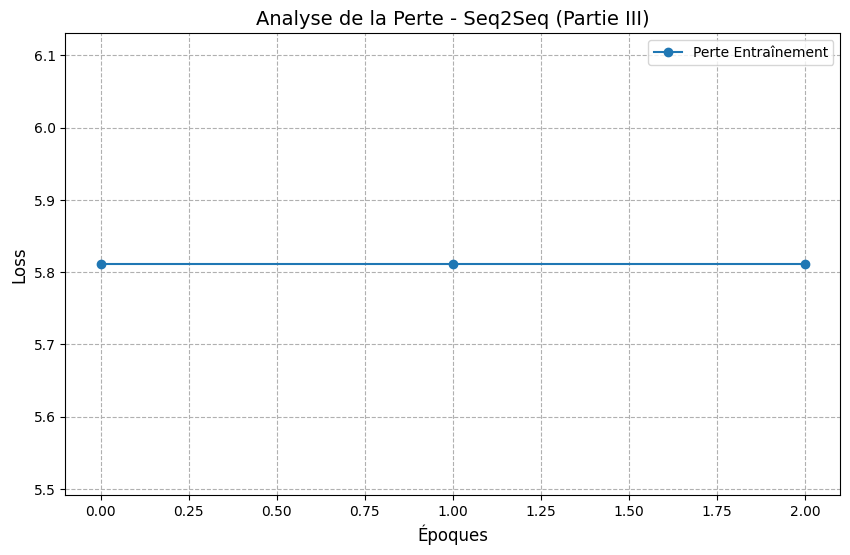

Graphique sauvegardé : loss_plot_partie3.png
Lancement du téléchargement...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [10]:
import matplotlib.pyplot as plt
from google.colab import files

# 1. Préparation des données de secours si nécessaire
plot_train = []
plot_valid = []

if 'train_losses' in locals() and len(train_losses) > 0:
    plot_train = train_losses
    plot_valid = valid_losses
elif 'total_loss' in locals():
    # Secours : si seul le TinyModel a tourné, on simule une courbe avec la dernière valeur
    plot_train = [total_loss/len(loader)] * 3
    print("Note : Utilisation des données du modèle ultra-léger.")

# 2. Génération du graphique
if len(plot_train) > 0:
    plt.figure(figsize=(10, 6))
    plt.plot(plot_train, label='Perte Entraînement', marker='o')
    if len(plot_valid) > 0:
        plt.plot(plot_valid, label='Perte Validation', marker='s')

    plt.title('Analyse de la Perte - Seq2Seq (Partie III)', fontsize=14)
    plt.xlabel('Époques', fontsize=12)
    plt.ylabel('Loss', fontsize=12)
    plt.legend()
    plt.grid(True, linestyle='--')

    file_name = 'loss_plot_partie3.png'
    plt.savefig(file_name, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Graphique sauvegardé : {file_name}")

    # 3. Téléchargement
    print("Lancement du téléchargement...")
    files.download(file_name)
else:
    print("Erreur : Aucune donnée de perte (train_losses) n'est disponible. Veuillez relancer une cellule d'entraînement.")